In [44]:
import deepinv as dinv
import torch
import numpy as np
import pywt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = torch.manual_seed(0)  # Random seed for reproducibility

In [ ]:
def wavelet_numpy_to_torch(coeffs, device=device):
    """
    Convert wavelet coefficients from NumPy arrays to PyTorch tensors.
    """
    approx_np = coeffs[0]
    details_np = coeffs[1:]

    # Convert approximation coefficients
    approx_torch = torch.from_numpy(approx_np.astype(np.float32)).to(device)

    # Convert detail coefficients efficiently
    details_torch = []
    for detail in details_np:
        if isinstance(detail, tuple) and len(detail) == 3:
            # detail is a tuple of (horizontal, vertical, diagonal) arrays
            h_arr, v_arr, d_arr = detail

            # Ensure arrays are contiguous and float32
            h_arr = np.ascontiguousarray(h_arr.astype(np.float32))
            v_arr = np.ascontiguousarray(v_arr.astype(np.float32))
            d_arr = np.ascontiguousarray(d_arr.astype(np.float32))

            # Stack the three arrays into a single array with shape [3, ...]
            detail_stacked = np.stack([h_arr, v_arr, d_arr], axis=0)

            # Convert to torch tensor
            detail_torch = torch.from_numpy(detail_stacked).to(device)
            details_torch.append(detail_torch)
        else:
            # Fallback for other formats
            if not detail.flags.c_contiguous:
                detail = np.ascontiguousarray(detail)
            if detail.dtype != np.float32:
                detail = detail.astype(np.float32)

            detail_torch = torch.from_numpy(detail).to(device)
            details_torch.append(detail_torch)

    return [approx_torch, *details_torch]

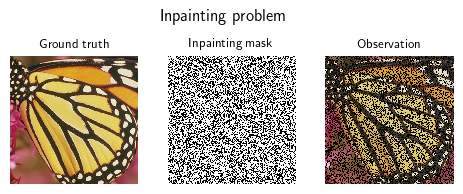

In [46]:
# Ground truth image
x_true = dinv.utils.load_example('butterfly.png', device=device)

# Physics model
sigma = 0.01
noise_model = dinv.physics.GaussianNoise(sigma=sigma)
physics = dinv.physics.Inpainting(img_size=x_true.shape[1:], mask=0.6, device=device, noise_model=noise_model) # Keeping 60% of the pixels

mask = physics.mask.data.to(device)

# Observation
y = physics(x_true)

dinv.utils.plot([x_true, mask, y], titles=['Ground truth', 'Inpainting mask', 'Observation'], suptitle='Inpainting problem')

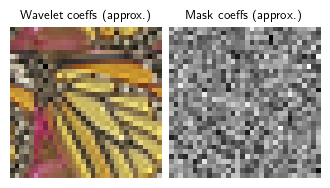

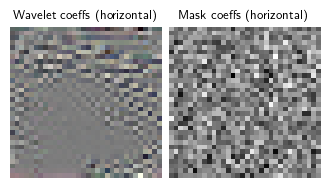

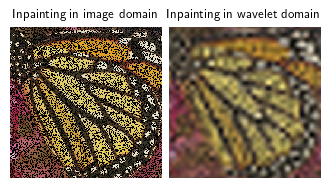

Norm of the difference between the two measurements:  5295.87646484375


In [48]:
# Compute wavelet coefficients of the image and of the mask
x_wavelet = wavelet_numpy_to_torch(pywt.wavedec2(x_true.cpu().numpy(), wavelet='db8', level=3, mode='periodization'))
mask_wavelet = wavelet_numpy_to_torch(pywt.wavedec2(mask.cpu().numpy(), wavelet='db8', level=3, mode='periodization'))

# Example of the coefficients
dinv.utils.plot([x_wavelet[0], mask_wavelet[0]], titles=['Wavelet coeffs (approx.)', 'Mask coeffs (approx.)'])
dinv.utils.plot([x_wavelet[1][0], mask_wavelet[1][0]], titles=['Wavelet coeffs (horizontal)', 'Mask coeffs (horizontal)'])

# Compute the coarse physics by using the wavelet coefficients of the fine mask as new masks for inpainting operators
coarse_physics = dinv.physics.Inpainting(img_size=x_wavelet[0].shape[1:], mask=mask_wavelet[0], device=device, noise_model=noise_model)
y_wavelet = [coarse_physics(x_wavelet[0])]

for i in range(1, len(x_wavelet)):
    details_tuple = tuple(
        dinv.physics.Inpainting(
            img_size=x_wavelet[i][j].shape[1:],
            mask=mask_wavelet[i][j],
            device=device,
            noise_model=noise_model
        )(x_wavelet[i][j])
        for j in range(3)
    )
    y_wavelet.append(details_tuple)  # append un tuple, pas un flatten de 3 arrays

# Reconstruct the image from the wavelet measurements
y_recon = pywt.waverec2(y_wavelet, wavelet='db8', mode='periodization')
y_recon = torch.tensor(y_recon, device=device)

# Plot the results : measurement in image domain vs measurement in wavelet domain
dinv.utils.plot([y, y_recon], titles=['Inpainting in image domain', 'Inpainting in wavelet domain'])
print("Norm of the difference between the two measurements: ", torch.norm(y - y_recon).item())
